In [1]:
# 检查NumPy GPU加速
try:
    import cupy as np
    print(f"CuPy (GPU) 可用: {np.cuda.runtime.runtimeGetVersion()}")
    print(f"GPU设备: {np.cuda.Device(0)}")
    USING_GPU = True
except ImportError:
    print("CuPy 不可用，NumPy使用CPU计算")
    import numpy as np
    USING_GPU = False


CuPy (GPU) 可用: 12090
GPU设备: <CUDA Device 0>


In [2]:
from PIL import Image
import os
from pathlib import Path

# 检查NumPy底层数学库
print(f"NumPy版本: {np.__version__}")
np.show_config()

NumPy版本: 14.1.1
OS                           : Windows-10-10.0.19045-SP0
Python Version               : 3.14.5
CuPy Version                 : 14.1.1
CuPy Platform                : NVIDIA CUDA
NumPy Version                : 2.4.6
SciPy Version                : 1.17.1
Cython Build Version         : 3.2.4
Cython Runtime Version       : None
CUDA Root                    : C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8
NVCC PATH                    : C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8\bin\nvcc.exe
CUDA Build Version           : 12090
CUDA Driver Version          : 13000
CUDA Runtime Version         : 12090 (linked to CuPy) / 12080 (locally installed)
CUDA Extra Include Dirs      : ['C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v12.8\\include']
cuBLAS Version               : (available)
cuFFT Version                : 11303
cuRAND Version               : 10309
cuSOLVER Version             : (11, 7, 2)
cuSPARSE Version             : (available)
NVRTC Ve

In [3]:
# 配置路径
source_dir = Path("Item_Origine")
output_dir = Path("Item")

# 画布尺寸
CANVAS_SIZE = 256

# 缩放比例 (0.0 - 1.0)
SCALE_RATIO = 0.1

# 外边缘线宽度（像素）
OUTLINE_WIDTH = 8


MIN_SCALE = 204

In [4]:
def create_smooth_outline(alpha_array, outline_width):
    """
    为透明区域创建平滑过渡的外边缘线
    使用距离变换实现渐变效果
    """
    from scipy import ndimage
    
    # 创建二值mask：不透明区域为True
    opaque_mask = alpha_array.get() > 0
    
    # 计算透明区域到不透明边缘的距离
    distance = ndimage.distance_transform_edt(~opaque_mask)
    
    # 创建平滑过渡的边缘线
    # 距离在 outline_width 范围内的像素会有渐变透明度
    outline_alpha = np.clip(outline_width - distance, 0, 1)
    
    # 只保留透明区域的边缘线（不覆盖原图）
    # outline_alpha[opaque_mask] = 0
    
    return outline_alpha

In [5]:
def process_image(input_path, output_path, outline_color=None, canvas_size=256, scale_ratio=1, outline_width=8, min_scale_size = 128):
    """
    处理单张图片:
    1. 按固定比例缩放
    2. blit到画布中心
    3. 绘制透明区域外边缘线
    """
    # 打开源图片
    src_img = Image.open(input_path).convert("RGBA")
    src_w, src_h = src_img.size
    
    # 计算缩放后的尺寸（保持宽高比）
    new_w = int(src_w * scale_ratio)
    new_h = int(src_h * scale_ratio)
    if(new_h <= new_w and new_w < min_scale_size):
        new_h = int(min_scale_size * src_h / src_w)
        new_w = min_scale_size
    if(new_w <= new_h and new_h < min_scale_size):
        new_w = int(min_scale_size * src_w / src_h)
        new_h = min_scale_size
    # 缩放图片
    scaled_img = src_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    # 创建画布
    canvas = Image.new("RGBA", (canvas_size, canvas_size), (0, 0, 0, 0))
    
    # 计算居中位置
    paste_x = (canvas_size - new_w) // 2
    paste_y = (canvas_size - new_h) // 2
    
    # 将缩放后的图片blit到画布上
    canvas.paste(scaled_img, (paste_x, paste_y))
    
    if (outline_width > 0):
        # 转换为numpy数组处理边缘线
        canvas_array = np.array(canvas, dtype=np.float32)
        alpha = canvas_array[:, :, 3] / 255
        
        # 创建平滑边缘线
        outline_alpha = create_smooth_outline(alpha, outline_width)
        if outline_color is None:
            outline_color = (0, 0, 0)  # RGB
        
        # 应用平滑边缘线
        for c in range(3):
            canvas_array[:, :, c] *= alpha
            canvas_array[:, :, c] += (1 - alpha) * outline_color[c]
        # 更新alpha通道
        canvas_array[:, :, 3] = np.asarray(outline_alpha * 255)
    
        # 转换回uint8并保存
        canvas_array = np.clip(canvas_array, 0, 255).astype(np.uint8)
        result_img = Image.fromarray(canvas_array.get())
    else:
        result_img = canvas
    
    result_img.save(output_path)
    return result_img

In [6]:
# 处理所有图片
image_files = list(source_dir.rglob("*.png"))
print(f"找到 {len(image_files)} 张图片")

for img_path in image_files:
    # 保持目录结构输出
    rel_path = img_path.relative_to(source_dir)
    output_path = output_dir / rel_path
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    process_image(img_path, output_path, [0,0,0], CANVAS_SIZE, SCALE_RATIO, OUTLINE_WIDTH)
    print(f"已处理: {rel_path}")

print(f"\n完成! 共处理 {len(image_files)} 张图片")

找到 75 张图片
已处理: Ace_107.png
已处理: Arrow_1_347.png
已处理: Augewehr_1362.png
已处理: Avenger_1021.png
已处理: Backlash_3520.png
已处理: Bane_1484.png
已处理: Bluntforce_112.png
已处理: Bow_Compound_357.png
已处理: Bulldog_1369.png
已处理: Card_1379.png
已处理: Chimera_3512.png
已处理: Cobalt_15041.png
已处理: Cobra_99.png
已处理: Colt_97.png
已处理: Crossbow_346.png
已处理: Dagger_15044.png
已处理: Desert_Falcon_488.png
已处理: Determinator_1480.png
已处理: Dragonfang_132.png
已处理: Eaglefire_4.png
已处理: Ekho_1382.png
已处理: Empire_1481.png
已处理: Flashbang_1346.png
已处理: Fury_1364.png
已处理: Fusilaut_1375.png
已处理: Grenade_254.png
已处理: Grizzly_297.png
已处理: Hawkhound_109.png
已处理: Heartbreaker_1037.png
已处理: Hollowcharge_15050.png
已处理: Honeybadger_116.png
已处理: Hospitality_15048.png
已处理: Impact_Grenade_1520.png
已处理: Judgement_15053.png
已处理: Kopis_3515.png
已处理: Kryzkarek_1039.png
已处理: Lancer_3517.png
已处理: Launcher_Rocket_519.png
已处理: Lockdown_3522.png
已处理: Luger_1476.png
已处理: Maplestrike_363.png
已处理: Masterkey_380.png
已处理: Matamorez_1000.png
已处理: MP40_1

原图/处理后:


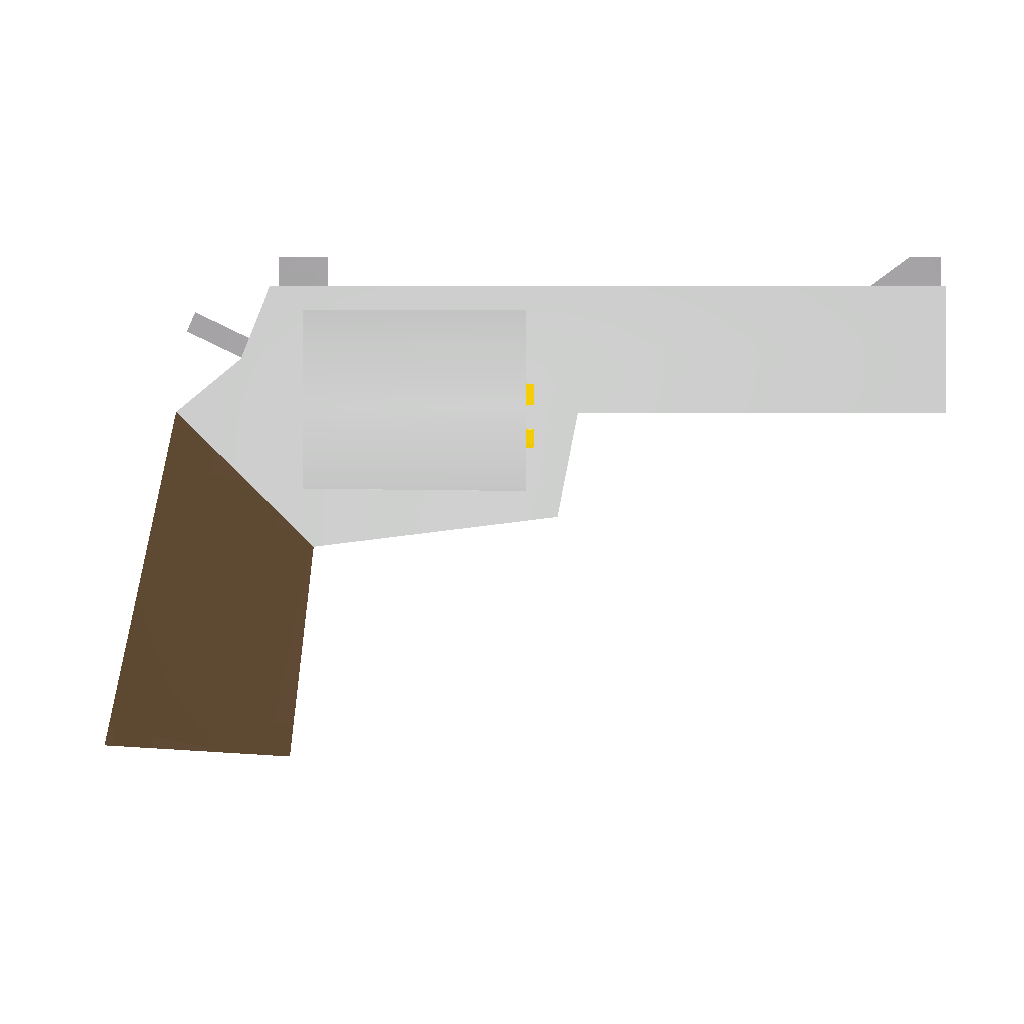

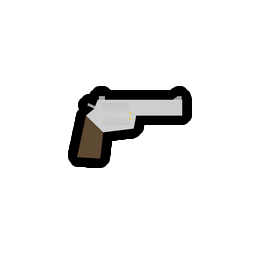

In [7]:
# 预览第一张图片的处理结果
if image_files:
    from IPython.display import display
    
    # 显示原图和处理后的图片对比
    first_img = image_files[0]
    rel_path = first_img.relative_to(source_dir)
    original = Image.open(first_img)
    processed = Image.open(output_dir / rel_path)
    
    print("原图/处理后:")
    display(original,processed)